<img
    src="https://www.ingenieurs.com/images/article/1515_1.jpg" 
    alt=""
    height="200px" 
    width="200px"
    align=left
/> 
<br>
<br>

<center> <br>
  <h2 style="color:#7c7979";>USAE08 - Mathématiques de l'ingénieur 2</h2>
</center>   

<center>
  <h2 style="color:#000000";>TP 7 : Résolution de l'équation de Poisson 1D (II) </h2>
  <h2 style="color:#000000";>Conditions de bord de type Dirichlet et Neumann </h2>
</center>

# Questions du TP 

On se propose d'étudier les 3 problèmes de Poisson suivants :
* **Problème 1** :
    * RHS 1 : $f(x)=\dfrac{k^2 \pi^2}{L_x^2} \sin\big(\frac{k\pi x}{L_x} \big)$ avec $k=1$
    * Solution exacte associée : $u_{ex}(x) =\sin\big(\frac{k\pi x}{L_x} \big)$ avec $k=1$
    * type CL : 
        * Dirichlet Gauche homogène : $u(0)=0$ (`param.DirG=1`, `param.alpha=0.`)
        * Dirichlet Droite homogène : $u(L_x)=0$ (`param.DirD=1`, `param.beta=0.`)
* **Problème 2** :
    * RHS 2 : $f(x)=\dfrac{k^2 \pi^2}{L_x^2} \cos\big(\frac{k\pi x}{L_x} \big)$ avec $k=3$
    * Solution exacte associée : $u_{ex}(x) =\cos\big(\frac{k\pi x}{L_x} \big)$ avec $k=3$
    * type CL : 
        * Dirichlet Gauche non-homogène : $u(0)=\alpha=1$ (`param.DirG=1`, `param.alpha=1.`)
        * Dirichlet Droite non-homogène : $u(L_x)=\beta=-1$ (`param.DirD=1`, `param.beta=-1.`)
* **Problème 3** :
    * RHS 1 : $f(x)=\dfrac{k^2 \pi^2}{L_x^2} \sin\big(\frac{k\pi x}{L_x} \big)$ avec $k=1$
    * Solution exacte associée : $u_{ex}(x) =\sin\big(\frac{k\pi x}{L_x} \big)$ avec $k=1$
    * type CL (mixtes) : 
        * Dirichlet Gauche homogène : $u(0)=0$ (`param.DirG=1`, `param.alpha=0.`)
        * Neumann Droite non-homogène : $u'(L_x)=\beta=-\dfrac{k \pi}{L_x}$ (`param.NeuD=1`, `param.beta=-k*pi/Lx.`)

In [1]:
# Import des packages python
%matplotlib notebook
%matplotlib inline
import time
import numpy as np
import scipy.linalg as sp_linalg
import scipy.optimize as sp_optimize
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from math import sin, cos, pi, log, exp

In [2]:
class Param (object) : 
    def __init__ (self):
        # Probleme de Poisson et CL
        self.problem = 1 # (integer) numéro du problème choisi (1, 2 ou 3)
        self.DirG = 0 # (boolean) Est-ce que la condition Dirichlet à gauche (G) est activée ? 0 = Non, 1 = Oui
        self.DirD = 0 # (boolean) Est-ce que la condition Dirichlet à droite (D) est activée ? 0 = Non, 1 = Oui
        self.NeuG = 0 # (boolean) Est-ce que la condition Neumann à gauche (G) est activée ? 0 = Non, 1 = Oui
        self.NeuD = 0 # (boolean) Est-ce que la condition Neumann à droite (D) est activée ? 0 = Non, 1 = Oui
        self.alpha = 0. # (float) Valeur condition limite
        self.beta = 0. # (float) Valeur condition limite
        # Domaine et discrétisation
        self.Lx = 1
        self.nx = 16 # nombre de cellules dans le maillage (nombre entier)
        self.dx = 0.
        self.x = np.zeros(self.nx + 1) # tableau des coordonées x dans le maillage

Voici ci-dessous la fonction python `define_problem` dont le rôle est d'implémenter les 3 problèmes de Poisson ci-dessus en précisant dans chaque cas :
* la solution exacte
* le second membre 
* les conditions limites.   

En sortie, la fonction renvoie la solution exacte et le second membre. 

Elle fait appel aux attributs suivants de la classe Param :
* `type_problem` : pour le choix du problème
* `DirG`, `DirD`, `NeuG`, `NeuD`, `alpha`, `beta` : pour la définition des conditions limites

In [3]:
def define_problem(param) :
    u_ex = np.zeros(param.nx + 1)
    if param.problem == 1 :
        u_ex = np.sin(np.pi * param.x / param.Lx)
        rhs = (np.pi**2 / param.Lx**2) * u_ex
        param.DirG = 1
        param.NeuG = 0
        param.alpha = 0.
        param.DirD = 1
        param.NeuD = 0
        param.beta = 0.
    elif param.problem == 2 :        
        k = 3.
        u_ex = np.cos(k * np.pi * param.x / param.Lx)
        rhs = (k**2 * np.pi**2 / param.Lx**2) * u_ex
        param.DirG = 1
        param.NeuG = 0
        param.alpha = 1.
        param.DirD = 1
        param.NeuD = 0
        param.beta = -1.
    elif param.problem == 3 :
        u_ex = np.sin(np.pi * param.x / param.Lx)
        rhs = (np.pi**2 / param.Lx**2) * u_ex
        param.DirG = 1
        param.NeuG = 0
        param.alpha = 0.
        param.DirD = 0
        param.NeuD = 1
        param.beta = - np.pi / param.Lx
    else :
        raise ValueError("problem != {1;2;3}")
    return u_ex, rhs # 2 vecteurs de tailles nx+1

**1)** Compléter la fonction python `assembleRHS` ci-dessous qui renvoie en sortie le vecteur $F \in \mathbb{R}^{N+1}$ second membre de l'équation de Poisson matricielle selon le type de conditions limites pouvant être spécifiées dans le problème.   

**Remarque** : le cas `param.NeuG` = `param.NeuD` = `1`, nécessitant d'avoir 1 inconnue du problème en moins (c'est à dire nécessitant une condition de type Dirichlet sur un point quelconque du domaine intérieur), ne sera pas traité dans le cadre de ce TP.

In [42]:
def assembleRHS(rhs, param) :
    '''
    Entrées :
    @rhs : tableau (vecteur colonne) (f0, f1, ..., fN)
    
    Sorties : 
    @rhs = le vecteur second membre complet (avec les dx^2 et les CL)
    '''
    rhs = param.dx ** 2 * rhs
    if param.DirG and param.DirD :
    #if param.DirG == 1 and param.DirD == 1 :
        rhs[0], rhs[-1] = param.alpha, param.beta
        rhs[1] = rhs[1] + param.alpha
        rhs[-2] = rhs[-2] + param.beta
    elif param.DirG and param.NeuD :
        rhs[0] = param.alpha
        rhs[1] = rhs[1] + param.alpha
        rhs[-1] = param.beta * param.dx
    elif param.NeuG and param.DirD :
        rhs[0] = param.alpha * param.dx
        rhs[-2] = rhs[-2] + param.beta
        rhs[-1] = param.beta
    else :
        raise ValueError('Cas non traité (NeuG et NeuD)')
    return rhs

**2)** Compléter la fonction python `assembleMat` ci-dessous qui renvoie en sortie la matrice $A \in \mathcal{M}_{N+1,N+1}$ de l'équation de Poisson matricielle selon le type de conditions limites pouvant être spécifiées dans le problème.   

**Remarque** : idem, le cas `param.NeuG` = `param.NeuD` = `1` ne sera pas traité.

In [34]:
def assembleMat(param) :
    A = np.zeros((param.nx + 1, param.nx + 1))
    for i in range(1, param.nx - 1):
        A[i, i] = 2 # diagonale
        A[i + 1, i] = -1 # sous-diagonale
        A[i, i + 1] = -1 # sur-diagonale
    
    A[0, 0] = 1
    A[-1, -1] = 1
    A[-2, -2] = 2
    
    if param.DirG and param.DirD :
    #if param.DirG == 1 and param.DirD == 1 :
        pass
        
    elif param.DirG and param.NeuD :
        A[-2, -1] = A[-1, -2] = -1
        
    elif param.NeuG and param.DirD :
        A[0, 1] = A[1, 0] = -1
        
    else :
        raise ValueError('Cas non traité (NeuG et NeuD)')
    return A

Soit la fonction `isoplot1d` donnée ci-dessous (complète) permettant de tracer sur un même graphique la solution exacte et la solution approchée du problème de Poisson :

In [14]:
def isoplot1d(u, u_ex, param) :
    ''' Fonction pour l'affichage graphique des solutions 1D '''
    # Setup figures
    fig, ax = plt.subplots(figsize=(4,4))
    ax.set_xlim(-.01, param.Lx + 0.01)
    ax.set_title('probleme de Poisson en 1D') 
    ax.set_xlabel('x')
    absx = np.linspace(0, param.Lx, param.nx+1)

    # Tracé des courbes des solutions exacte et approchee :
    couleur = 'blue'
    if (param.problem <= 3):
        # Stockage de la premiere ligne de la solution exacte dans un vecteur 1D 
        uuex = np.zeros(param.nx+1)
        uuex[0:param.nx+1] = u_ex[0:param.nx+1]    
        ax.plot (absx, uuex, couleur, label='solution exacte')

    j = 0 
    uu = np.zeros(param.nx + 1)
    uu[0:param.nx+1]= u[j*(param.nx+1):(j+1)*(param.nx+1)]    
    ax.plot (absx, uu, color='red', marker='*' , lw=0, label='solution approchee  ')
    ax.legend(loc='lower center')

    return

**3)** Compléter la fonction python ci-dessous `main_Poisson` (programme principal) dont le rôle est d'appeler toutes les étapes nécessaires à la résolution numérique du problème de Poisson.

In [43]:
def main_Poisson(param):
    """
    Programme principal pour la résolution numérique du problème de Poisson :
    -d2u / dx2 = f(x) 
    avec CL gauche et droite
    """
    # Définition du pas d'espace et les coordonnées x_i des points du maillage
    param.dx = param.Lx / param.nx
    param.x = np.linspace(0, param.Lx, param.nx + 1)
 
    # Calcul de la solution exacte (si disponible)
    sol_ex, rhs = define_problem(param)
 
    # Assemblage plein de la matrice 
    A = assembleMat(param)
    
    # Assemblage du vecteur second membre (RHS)
    rhs = assembleRHS(rhs,param)
 
    # Resolution du systeme lineaire, matrice pleine   
    sol_approchee = np.linalg.solve(A,rhs)
        
    # Représentation 1D de la solution
    isoplot1d(sol_approchee, sol_ex, param)
    
    return

**4)** Avant de résoudre les 3 problèmes, valider l'assemblage plein de la matrice $A$ dans les 3 cas de figure suivants :
* Dirichlet - Dirichlet
* Dirichlet - Neumann
* Neumann - Dirichlet

On s'assurera dans chaque cas que la matrice $A$ a bien la structure et les coefficients attendus. On pourra prendre `param.nx=10` (c'est à dire une matrice de taille $11 \times 11$) pour ces tests.

In [44]:
# Test pour DirG-DirD
param = Param()
param.nx = 10
param.DirG = 1
param.DirD = 1
param.NeuG = 0
param.NeuD = 0
assembleMat(param)

array([[ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  2., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0., -1.,  2., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0., -1.,  2., -1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0., -1.,  2., -1.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0., -1.,  2., -1.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0., -1.,  2., -1.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., -1.,  2., -1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  2., -1.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  2.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]])

In [45]:
# Test pour DirG-NeuD
param = Param()
param.nx = 10
param.DirG = 1
param.DirD = 0
param.NeuG = 0
param.NeuD = 1
assembleMat(param)

array([[ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  2., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0., -1.,  2., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0., -1.,  2., -1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0., -1.,  2., -1.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0., -1.,  2., -1.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0., -1.,  2., -1.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., -1.,  2., -1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  2., -1.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  2., -1.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  1.]])

In [46]:
# Test pour NeuG-DirD
param = Param()
param.nx = 10
param.DirG = 0
param.DirD = 1
param.NeuG = 1
param.NeuD = 0
assembleMat(param)

array([[ 1., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [-1.,  2., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0., -1.,  2., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0., -1.,  2., -1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0., -1.,  2., -1.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0., -1.,  2., -1.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0., -1.,  2., -1.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., -1.,  2., -1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  2., -1.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  2.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]])

**5) Simulations :** Tester votre calcul de la solution approchée pour les 3 problèmes implémentés : on définira pour cela les attributs de `param` souhaités et on appellera le programme principal `main_Poisson`.

**Simulation problème 1** : 

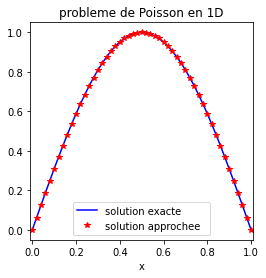

In [52]:
param = Param()

# Paramètres de simulation
param.problem = 1
param.nx = 50

# Appel du programme principal
main_Poisson(param)

**Simulation problème 2** : 

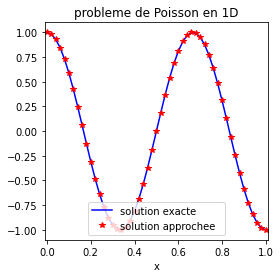

In [50]:
param = Param()

# Paramètres de simulation
param.problem = 2
param.nx = 50

# Appel du programme principal
main_Poisson(param)

**Simulation problème 3** : 

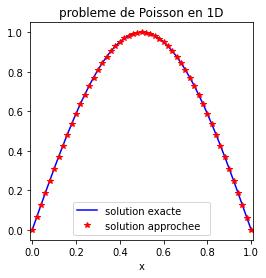

In [51]:
param = Param()

# Paramètres de simulation
param.problem = 3
param.nx = 50

# Appel du programme principal
main_Poisson(param)